<a href="https://colab.research.google.com/github/Praveen21-06/DL-LAB-WORK/blob/main/DL_LAB_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step-by-step RNN computation:

Time step 1:
Input x_1 = 1.0
h_1 = tanh(0.5*1.0 + 0.8*0.0 + 0.1) = 0.5370

Time step 2:
Input x_2 = 2.0
h_2 = tanh(0.5*2.0 + 0.8*0.5370495669980352 + 0.1) = 0.9104

Time step 3:
Input x_3 = 3.0
h_3 = tanh(0.5*3.0 + 0.8*0.9103629086462668 + 0.1) = 0.9812

Time step 4:
Input x_4 = 4.0
h_4 = tanh(0.5*4.0 + 0.8*0.9811809858525657 + 0.1) = 0.9938

Time step 5:
Input x_5 = 5.0
h_5 = tanh(0.5*5.0 + 0.8*0.9937792054635632 + 0.1) = 0.9978

Final Hidden States: [np.float64(0.5370495669980352), np.float64(0.9103629086462668), np.float64(0.9811809858525657), np.float64(0.9937792054635632), np.float64(0.9977526956150692)]


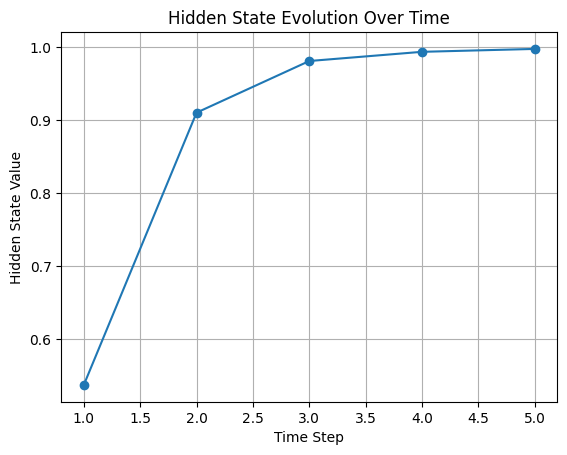

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = [1.0, 2.0, 3.0, 4.0, 5.0]

Wx = 0.5
Wh = 0.8
b = 0.1
h_prev = 0.0
def tanh(x):
    return np.tanh(x)
hidden_states = []
print("Step-by-step RNN computation:\n")
for t, x_t in enumerate(X):
    h_t = tanh(Wx * x_t + Wh * h_prev + b)

    print(f"Time step {t+1}:")
    print(f"Input x_{t+1} = {x_t}")
    print(f"h_{t+1} = tanh({Wx}*{x_t} + {Wh}*{h_prev} + {b}) = {h_t:.4f}\n")

    hidden_states.append(h_t)
    h_prev = h_t

print("Final Hidden States:", hidden_states)

plt.figure()
plt.plot(range(1, len(hidden_states)+1), hidden_states, marker='o')
plt.title("Hidden State Evolution Over Time")
plt.xlabel("Time Step")
plt.ylabel("Hidden State Value")
plt.grid()
plt.show()

In [ ]:
import numpy as np

# -------------------------
# 1. Input
# -------------------------
X = [1.0, 2.0, 3.0]
target = 0.5

# -------------------------
# 2. Parameters
# -------------------------
Wx = 0.5
Wh = 0.8
Wy = 1.0
b = 0.0
lr = 0.01

# -------------------------
# 3. Functions
# -------------------------
def tanh(x):
    return np.tanh(x)

def dtanh(x):
    return 1 - np.tanh(x)**2

# -------------------------
# 4. Forward Pass
# -------------------------
h = [0.0]

for t in range(len(X)):
    h_t = tanh(Wx * X[t] + Wh * h[t] + b)
    h.append(h_t)

y_pred = Wy * h[-1]
loss = 0.5 * (y_pred - target)**2

print("Prediction:", y_pred)
print("Loss:", loss)

# -------------------------
# 5. Backward Pass (BPTT)
# -------------------------
dWx, dWh, dWy, db = 0, 0, 0, 0

dy = (y_pred - target)
dWy = dy * h[-1]

dh_next = dy * Wy

for t in reversed(range(len(X))):
    z = Wx * X[t] + Wh * h[t] + b
    dh = dh_next * dtanh(z)

    dWx += dh * X[t]
    dWh += dh * h[t]
    db  += dh

    dh_next = dh * Wh

print("\nGradients:")
print("dWx:", dWx)
print("dWh:", dWh)
print("dWy:", dWy)
print("db :", db)

# -------------------------
# 6. Update
# -------------------------
Wx -= lr * dWx
Wh -= lr * dWh
Wy -= lr * dWy
b  -= lr * db

print("\nUpdated Parameters:")
print("Wx:", Wx)
print("Wh:", Wh)
print("Wy:", Wy)
print("b :", b)

Prediction: 0.9758816208890569
Loss: 0.11323165854999806

Gradients:
dWx: 0.07891109556468734
dWh: 0.02183728310022592
dWy: 0.4644041275445246
db : 0.029417849139385555

Updated Parameters:
Wx: 0.4992108890443531
Wh: 0.7997816271689978
Wy: 0.9953559587245547
b : -0.00029417849139385554


Hidden States: [np.float64(0.6043677771171634), np.float64(0.9382301336849398), np.float64(0.9880422042543157), np.float64(0.9966264851198514), np.float64(0.9989948641704799)]
Prediction: 1.1987938370045759
Loss: 0.24415641331778887

Gradients:
dWx: 0.008456556771505619
dWh: 0.001687167232643146
dWy: 0.6980914542815547
db : 0.0016929636365441265

Updated Parameters:
Wx: 0.5999154344322849
Wh: 0.6999831283276735
Wy: 1.1930190854571845
b : 0.09998307036363456


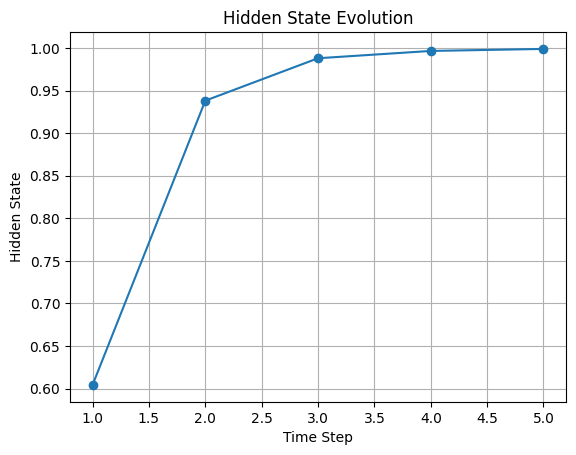

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. Configurable Inputs
# -------------------------
X = [1.0, 2.0, 3.0, 4.0, 5.0]
target = 0.5

# -------------------------
# 2. Configurable Parameters
# -------------------------
Wx = 0.6
Wh = 0.7
Wy = 1.2
b = 0.1
lr = 0.01

# -------------------------
# 3. Functions
# -------------------------
def tanh(x):
    return np.tanh(x)

def dtanh(x):
    return 1 - np.tanh(x)**2

# -------------------------
# 4. Forward Pass
# -------------------------
h = [0.0]
z_vals = []

for t in range(len(X)):
    z = Wx * X[t] + Wh * h[t] + b
    h_t = tanh(z)

    z_vals.append(z)
    h.append(h_t)

y_pred = Wy * h[-1]
loss = 0.5 * (y_pred - target)**2

print("Hidden States:", h[1:])
print("Prediction:", y_pred)
print("Loss:", loss)

# -------------------------
# 5. Backward Pass (BPTT)
# -------------------------
dWx, dWh, dWy, db = 0, 0, 0, 0

dy = (y_pred - target)
dWy = dy * h[-1]

dh_next = dy * Wy

for t in reversed(range(len(X))):
    dh = dh_next * dtanh(z_vals[t])

    dWx += dh * X[t]
    dWh += dh * h[t]
    db  += dh

    dh_next = dh * Wh

print("\nGradients:")
print("dWx:", dWx)
print("dWh:", dWh)
print("dWy:", dWy)
print("db :", db)

# -------------------------
# 6. Update
# -------------------------
Wx -= lr * dWx
Wh -= lr * dWh
Wy -= lr * dWy
b  -= lr * db

print("\nUpdated Parameters:")
print("Wx:", Wx)
print("Wh:", Wh)
print("Wy:", Wy)
print("b :", b)

# -------------------------
# 7. Plot
# -------------------------
plt.figure()
plt.plot(range(1, len(h)), h[1:], marker='o')
plt.title("Hidden State Evolution")
plt.xlabel("Time Step")
plt.ylabel("Hidden State")
plt.grid()
plt.show()

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


vocab_size = 5000
max_len = 200
embed_size=32
hidden_size=32

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embed_size, input_length=max_len),
    SimpleRNN(hidden_size),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.6876 - loss: 0.5658
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.6952 - loss: 0.5861
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.8143 - loss: 0.4171
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.7367 - loss: 0.5315
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.7872 - loss: 0.4486
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.8646 - loss: 0.3200
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.8652 - loss: 0.3175
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9099 - loss: 0.2292
Epoch 9/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.8677 - loss: 0.3147
Epoch 10/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.9134 - loss: 0.2206
Epoch 11/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.9319 - loss: 0.1788
Epoch 12/20
782/782 ━━━━━━━━━━


Training with LR = 0.001
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.6482 - loss: 0.6122
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.8109 - loss: 0.4191
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.8735 - loss: 0.3047
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.8695 - loss: 0.3056
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.9371 - loss: 0.1660
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9660 - loss: 0.1007
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.9783 - loss: 0.0630
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.9842 - loss: 0.0482
Epoch 9/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.9874 - loss: 0.0398
Epoch 10/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.9915 - loss: 0.0272
Epoch 11/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.9299 - loss: 0.1912
Epoc

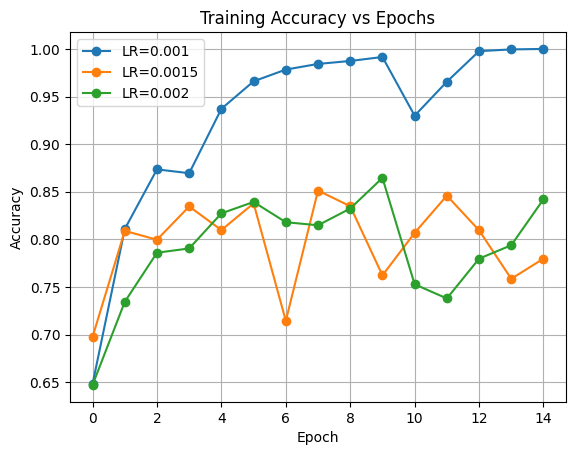

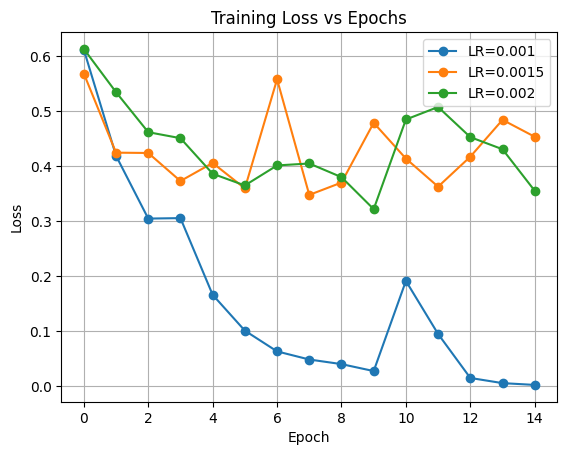

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

vocab_size = 5000
max_len = 200
embed_size = 32
hidden_size = 32
learning_rates = [0.001, 0.0015, 0.002]
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)
history_dict = {}
for lr in learning_rates:
    print(f"\nTraining with LR = {lr}")

    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_size, input_length=max_len),
        SimpleRNN(hidden_size),
        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=lr)

    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=32,
        verbose=1
    )

    history_dict[lr] = history.history
plt.figure()

for lr in learning_rates:
    plt.plot(history_dict[lr]['accuracy'], marker='o', label=f'LR={lr}')

plt.title("Training Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()
plt.figure()

for lr in learning_rates:
    plt.plot(history_dict[lr]['loss'], marker='o', label=f'LR={lr}')

plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()